# Stanford CME 241 (Winter 2026) - Assignment 1

**Due: Friday, January 23 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):*

https://github.com/my-username/my-repo/assignment-file-name.ipynb

*Group members (replace below names with people in your group):*
- Person 1
- Person 2
- Person 3

## Imports

In [6]:
import sys
import os

sys.path.append(os.path.abspath(".."))

## Question 1: Snakes and Ladders (Led by ______)

In the classic childhood game of Snakes and Ladders, all players start to the left of square 1 (call this position 0) and roll a 6-sided die to represent the number of squares they can move forward. The goal is to reach square 100 as quickly as possible. Landing on the bottom rung of a ladder allows for an automatic free-pass to climb, e.g. square 4 sends you directly to 14; whereas landing on a snake's head forces one to slide all the way to the tail, e.g. square 34 sends you to 6. Note, this game can be viewed as a Markov Process, where the outcome is only depedent on the current state and not the prior trajectory. In this question, we will ask you to both formally describe the Markov Process that describes this game, followed by coding up a version of the game to get familiar with the RL-book libraries.


### Problem Statement

How can we model this problem with a Markov Process?

---

### Subquestions

#### Part (A): MDP Modeling

Formalize the state space of the Snakes and Ladders game. Don't forget to specify the terminal state!

---

#### Part (B): Transition Probabilities

Write out the structure of the transition probabilities. Feel free to abbreviate all squares that do not have a snake or ladder.

---

#### Part (C): Modeling the Game

Code up a `transition_map: Transition[S]` data structure to represent the transition probabilities of the Snakes and Ladders Markov Process so you can model the game as an instance of `FiniteMarkovProcess`. Use the `traces` method to create sampling traces, and plot the graph of the distribution of time steps to finish the game. Use the image provided for the locations of the snakes and ladders.

https://drive.google.com/file/d/1yhP242sG092Ico_WOPKrUp8jVJHbuGHH/view?usp=sharing

---

### Part (A) Answer

<span style="color:red">*Let the board positions be numbered 0,1,2,..,100, where 0 is "left of square 1" and 100 is the goal. Because snakes and ladders act immediately after player land, it's clean to define the state as the player's post-resolution position. Then the state space is S = {0,1,2,...,100}. Terminal state: $s_T$ = 100 and it's abosorbing.*</span>

### Part (B) Answer

States are the board positions {0, 1, 2, ..., 100}, with state 100 as the terminal state.

Define a deterministic function f(i) to resolve snakes and ladders:
- If i is the bottom of a ladder, f(i) is the top of that ladder.
- If i is the head of a snake, f(i) is the tail of that snake.
- Otherwise, f(i) = i.
- Also define f(100) = 100.

From any non-terminal state s < 100, the player rolls a fair six-sided die.
Each outcome k in {1, 2, 3, 4, 5, 6} occurs with probability 1/6.

After rolling the die:
1. The player moves to square s + k (or to 100 if s + k > 100).
2. If the landing square is a snake or ladder square, the player is
   immediately moved according to f.

### Part (C) Answer

In [9]:

from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

In [10]:
from rl.distribution import Categorical
from rl.markov_process import FiniteMarkovProcess, NonTerminal, Terminal

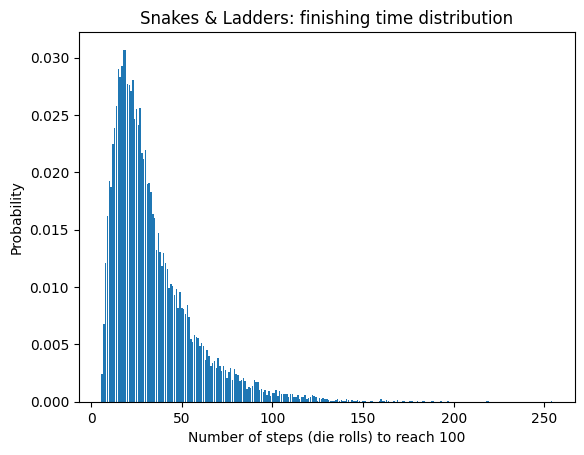

In [11]:
jumps = {
    1:38,
    4:14,
    8:30,
    21:42,
    28:74,
    32:10,
    36:6,
    48:26,
    50:67,
    62:18,
    71:92,
    80:99,
    88:24,
    95:56,
    97:78
}

def resolve(pos: int) -> int:

    return jumps.get(pos, pos)

def build_transition_map(cap_at_100: bool = True):
    tm = {}
    for s in range(0, 100):
        probs = {}
        for k in range(1, 7):
            if cap_at_100:
                landing = min(s + k, 100)
            else:
                landing = s + k if s + k <= 100 else s

            nxt = resolve(landing)
            probs[nxt] = probs.get(nxt, 0.0) + 1.0 / 6.0

        tm[s] = Categorical(probs)
    return tm

transition_map = build_transition_map(cap_at_100=True)
mp = FiniteMarkovProcess(transition_map)

start_dist = Categorical({NonTerminal(0): 1.0})

def finishing_time_from_trace(trace) -> int:
    steps = 0
    for st in trace:
        if isinstance(st, Terminal):
            return steps
        steps += 1
    raise RuntimeError("Trace did not terminate (check transition_map / rules).")

def sample_finish_times(n_episodes: int = 20000) -> np.ndarray:
    times = np.empty(n_episodes, dtype=int)
    trace_gen = mp.traces(start_dist)
    for i in range(n_episodes):
        tr = next(trace_gen)
        times[i] = finishing_time_from_trace(tr)
    return times

times = sample_finish_times(20000)
counts = Counter(times)
xs = np.array(sorted(counts.keys()))
ys = np.array([counts[x] for x in xs]) / len(times)

plt.figure()
plt.bar(xs, ys)
plt.xlabel("Number of steps (die rolls) to reach 100")
plt.ylabel("Probability")
plt.title("Snakes & Ladders: finishing time distribution")
plt.show()





## Question 2: Markov Decision Processes (Led by ______)

Consider an MDP with an infinite set of states ${S} = \{1,2,3,\ldots \}$. The start state is $s=1$. Each state $s$ allows a continuous set of actions $a \in [0,1]$. The transition probabilities are given by:
$$\mathbb{P}[s+1 \mid s, a] = a, \mathbb{P}[s \mid s, a] = 1 - a \text{ for all } s \in S \text{ for all } a \in [0,1]$$
For all states $s \in {S}$ and actions $a \in [0,1]$, transitioning from $s$ to $s+1$ results in a reward of $1-a$ and transitioning from $s$ to $s$ results in a reward of $1+a$. The discount factor $\gamma=0.5$.

### Problem Statement

How can we derive a mathematical formulation for the value function and the optimal policy? And how do those functions change when we modify the action space?

---

### Subquestions

#### Part (A): Optimal Value Function  

Using the MDP Bellman Optimality Equation, calculate the Optimal Value Function $V^*(s)$ for all $s \in {S}$. Given $V^*(s)$, what is the optimal action, $a^*$, that maximizes the optimal value function?

---

#### Part (B): Optimal Policy  

Calculate an Optimal Deterministic Policy $\pi^*(s)$ for all $s \in {S}$.

---

#### Part (C): Changing the Action Space  

Let's assume that we modify the action space such that instead of $a \in [0,1]$ for all states, we restrict the action space to $a \in \left[0,\frac{1}{s}\right]$ for state $s$. This means that higher states have more restricted action spaces. How does this constraint affect:

- The form of the Bellman optimality equation?
- The optimal value function, $V^*(s)$?
- The structure of the optimal policy, $\pi^*(s)$?

---

### Part (A) Answer


For any state $s\in S$ and action $a\in[0,1]$:

- With probability $a$ we move to $s+1$ and get reward $1-a$.
- With probability $1-a$ we stay at $s$ and get reward $1+a$.
- Discount factor $\gamma=0.5$.

So the Bellman optimality equation is
$$
V^*(s)=\max_{a\in[0,1]} \Big(
a\big[(1-a)+\gamma V^*(s+1)\big] + (1-a)\big[(1+a)+\gamma V^*(s)\big]
\Big).
$$

Expand the immediate-reward part:
$$
a(1-a) + (1-a)(1+a) = (a-a^2) + (1-a^2) = 1 + a - 2a^2.
$$

Thus
$$
V^*(s)=\max_{a\in[0,1]}\Big(
1+a-2a^2 + \gamma\big[(1-a)V^*(s)+aV^*(s+1)\big]
\Big),
\qquad \gamma=\frac12.
$$

---

### Step 1: Use translation invariance (state-homogeneity)

The dynamics and rewards do not depend on $s$, only on the action $a$ and whether we move or stay.  
Hence it is natural (and consistent) that the optimal value is constant across states:
$$
V^*(s)=V^*\quad \text{for all } s.
$$
Then $V^*(s+1)=V^*(s)=V^*$ and the discounted continuation term becomes
$$
\gamma\big[(1-a)V^*+aV^*\big]=\gamma V^*,
$$
which is independent of $a$.

So the Bellman equation reduces to
$$
V^*=\max_{a\in[0,1]}\Big(1+a-2a^2+\gamma V^*\Big).
$$

Rearrange:
$$
(1-\gamma)V^*=\max_{a\in[0,1]} \big(1+a-2a^2\big).
$$

With $\gamma=\frac12$:
$$
\frac12 V^*=\max_{a\in[0,1]} \big(1+a-2a^2\big).
$$

---

### Step 2: Maximize over $a$

Let
$$
f(a)=1+a-2a^2.
$$
Then
$$
f'(a)=1-4a.
$$
Set $f'(a)=0$:
$$
1-4a=0 \quad\Rightarrow\quad a^*=\frac14.
$$
Since
$$
f''(a)=-4<0,
$$
this is a maximizer. Also $a^*=\frac14\in[0,1]$.

Compute the maximum value:
$$
f\!\left(\frac14\right)=1+\frac14-2\left(\frac{1}{16}\right)=1+\frac14-\frac18=\frac{9}{8}.
$$

Thus
$$
\frac12 V^*=\frac{9}{8}\quad\Rightarrow\quad V^*=\frac{9}{4}.
$$

---

### Final answers

Optimal value function:
$$
V^*(s)=\frac{9}{4}\quad \text{for all } s\in\{1,2,3,\dots\}.
$$

Optimal action (same for every state):
$$
a^*(s)=\frac14\quad \text{for all } s.
$$


### Part (B) Answer


From Part (A), the Bellman optimality equation reduces to maximizing
$$
f(a)=1+a-2a^2
$$
since the continuation term equals $\gamma V^*$ and does not depend on $a$ when $V^*(s)$ is constant.

We found
$$
a^*=\arg\max_{a\in[0,1]} f(a)=\frac14,
\qquad
V^*(s)=\frac94 \ \text{for all } s.
$$

Therefore an optimal deterministic policy is the constant policy
$$
\pi^*(s)=\frac14 \quad \text{for all } s\in\{1,2,3,\dots\}.
$$



### Part (C) Answer

#### Bellman Optimality Equation Change:
For any state $s\ge 1$,
$$
V^*(s)=\max_{a\in[0,1/s]}
\Big(
a\big[(1-a)+\gamma V^*(s+1)\big] + (1-a)\big[(1+a)+\gamma V^*(s)\big]
\Big).
$$

As in Part (A), we can simplify the immediate-reward part:
$$
a(1-a)+(1-a)(1+a)=1+a-2a^2,
$$
so equivalently
$$
V^*(s)=\max_{a\in[0,1/s]}
\Big(
1+a-2a^2 + \gamma\big[(1-a)V^*(s)+aV^*(s+1)\big]
\Big),
\qquad \gamma=\frac12.
$$

#### Optimal Value Function Change:
With state-dependent action sets, the problem is no longer translation-invariant, so the constant-value conclusion from Part (A) need not hold.

However, we can still write a useful “difference form.”  Let
$$
\Delta_s := V^*(s+1)-V^*(s).
$$
Using $\gamma=\frac12$, the Bellman equation becomes
$$
V^*(s)=\max_{a\in[0,1/s]}
\Big(
1+a-2a^2 + \tfrac12 V^*(s) + \tfrac12 a\Delta_s
\Big),
$$
because
$$
\tfrac12\big[(1-a)V^*(s)+aV^*(s+1)\big]
=\tfrac12 V^*(s) + \tfrac12 a(V^*(s+1)-V^*(s))
=\tfrac12 V^*(s)+\tfrac12 a\Delta_s.
$$

Move the $\tfrac12 V^*(s)$ term to the left:
$$
\frac12 V^*(s)=\max_{a\in[0,1/s]}\Big(1+a-2a^2+\tfrac12 a\Delta_s\Big).
$$

So an exact characterization is
$$
V^*(s)=2\max_{a\in[0,1/s]}\Big(1+a-2a^2+\tfrac12 a\Delta_s\Big),
\qquad \Delta_s=V^*(s+1)-V^*(s).
$$

This is a coupled set of optimality conditions across all states.

Qualitatively, the constraint $a\le 1/s$ forces $a$ to be smaller at large $s$, which reduces the ability to “push” probability mass to $s+1$. Because moving to $s+1$ yields the smaller immediate reward $(1-a)$ compared to staying $(1+a)$, restricting $a$ tends to keep the optimal behavior closer to “stay” as $s$ grows. As a result:

- $V^*(s)$ will generally become state-dependent.
- For large $s$, since $1/s$ is small, the maximization is over very small $a$, and the solution approaches the boundary behavior near $a=0$.

A simple limiting intuition: if $a$ must be near $0$, then the process almost always stays and earns reward close to $1$, so values are dominated by repeated near-$1$ rewards, but the exact dependence on $s$ still flows through the coupling term $\Delta_s$.


#### Optimal Policy Change:
At each state $s$, the policy solves a one-dimensional concave maximization over a restricted interval.

For fixed $s$ and fixed $\Delta_s$, define
$$
g_s(a)=1+a-2a^2+\tfrac12 a\Delta_s.
$$
Then
$$
g_s'(a)=1-4a+\tfrac12 \Delta_s,
\qquad
g_s''(a)=-4<0,
$$
so $g_s$ is strictly concave and has a unique maximizer over any interval.

The unconstrained maximizer would be
$$
a_{\text{unc}}(s)=\frac{1+\tfrac12\Delta_s}{4}.
$$

With the constraint $a\in[0,1/s]$, the optimal deterministic action is the clipped version:
$$
\pi^*(s)=\arg\max_{a\in[0,1/s]} g_s(a)
=\min\left\{\frac{1}{s},\ \max\left\{0,\ \frac{1+\tfrac12\Delta_s}{4}\right\}\right\}.
$$

So the policy has a clear structure:

- It is state-dependent through the action cap $1/s$ and through $\Delta_s=V^*(s+1)-V^*(s)$.
- For sufficiently large $s$, the cap $1/s$ becomes small, so typically
  $$
  \pi^*(s)=\frac{1}{s}
  \quad \text{(boundary solution)}
  $$
  unless the clipped interior optimum is even smaller.
- In any case, $\pi^*(s)$ is nonnegative and cannot exceed $1/s$, so actions shrink as $s$ grows.

## Question 3: Frog in a Pond (Led by ______)

Consider an array of $n+1$ lilypads on a pond, numbered $0$ to $n$. A frog sits on a lilypad other than the lilypads numbered $0$ or $n$. When on lilypad $i$ ($1 \leq i \leq n-1$), the frog can croak one of two sounds: **A** or **B**.

- If it croaks **A** when on lilypad $i$ ($1 \leq i \leq n-1$):
  - It is thrown to lilypad $i-1$ with probability $\frac{i}{n}$.
  - It is thrown to lilypad $i+1$ with probability $\frac{n-i}{n}$.
  
- If it croaks **B** when on lilypad $i$ ($1 \leq i \leq n-1$):
  - It is thrown to one of the lilypads $0, \ldots, i-1, i+1, \ldots, n$ with uniform probability $\frac{1}{n}$.

A snake, perched on lilypad $0$, will eat the frog if it lands on lilypad $0$. The frog can escape the pond (and hence, escape the snake!) if it lands on lilypad $n$.

### Problem Statement

What should the frog croak when on each of the lilypads $1, 2, \ldots, n-1$, in order to maximize the probability of escaping the pond (i.e., reaching lilypad $n$ before reaching lilypad $0$)?

Although there are multiple ways to solve this problem, we aim to solve it by modeling it as a **Markov Decision Process (MDP)** and identifying the **Optimal Policy**.

---

### Subquestions

#### Part (A): MDP Modeling

Express the frog-escape problem as an MDP using clear mathematical notation by defining the following components:

- **State Space**: Define the possible states of the MDP.
- **Action Space**: Specify the actions available to the frog at each state.
- **Transition Function**: Describe the probabilities of transitioning between states for each action.
- **Reward Function**: Specify the reward associated with the states and transitions.

---

#### Part (B): Python Implementation

There is starter code below to solve this problem programatically. Fill in each of the $6$ `TODO` areas in the code. As a reference for the transition probabilities and rewards, you can make use of the example in slide 16/31 from the following slide deck: https://github.com/coverdrive/technical-documents/blob/master/finance/cme241/Tour-MP.pdf.

Write Python code that:

- Models this MDP.
- Solves the **Optimal Value Function** and the **Optimal Policy**.

Feel free to use/adapt code from the textbook. Note, there are other libraries that are needed to actually run this code, so running it will not do anything. Just fill in the code so that it could run assuming that the other libraries are present.

---

#### Part (C): Visualization and Analysis

What patterns do you observe for the **Optimal Policy** as you vary $n$ from $3$ to $25$? When the frog is on lilypad $13$ (with $25$ total), what action should the frog take? Is this action different than the action the frog should take if it is on lilypad $1$?

---

### Part (A) Answer

#### State Space:  
Each lilypad index is a state:
$$
S=\{0,1,2,\dots,n\}.
$$
The terminal (absorbing) states are:
$$
T=\{0,n\},
$$
where state $0$ means the frog is eaten, and state $n$ means the frog escapes.


#### Action Space:  

At any nonterminal state $i\in\{1,2,\dots,n-1\}$, the frog chooses one of two actions:
$$
A(i)=\{A,B\}.
$$
At terminal states, no action is needed (or we can define a dummy action):
$$
A(0)=A(n)=\{\text{stop}\}.
$$
#### Transition Function:  

The transition probabilities $P(s,a,s')$ are:

1) If the frog is at $i\in\{1,\dots,n-1\}$ and chooses action $A$:
$$
P(i,A,i-1)=\frac{i}{n},\qquad
P(i,A,i+1)=\frac{n-i}{n},
$$
and all other transitions have probability $0$.

2) If the frog is at $i\in\{1,\dots,n-1\}$ and chooses action $B$:
it jumps uniformly to any pad except $i$, i.e. to
$$
\{0,1,\dots,i-1,i+1,\dots,n\},
$$
so for any $j\in S$ with $j\ne i$,
$$
P(i,B,j)=\frac{1}{n},
$$
and
$$
P(i,B,i)=0.
$$

3) Terminal states are absorbing:
$$
P(0,\text{stop},0)=1,\qquad P(n,\text{stop},n)=1.
$$

#### Reward Function:  

Since the objective is to maximize the probability of reaching $n$ before $0$, a standard choice is an episodic terminal reward:

For any transition $(s,a,s')$,
$$
R(s,a,s')=
\begin{cases}
1, & s'=n,\\
0, & \text{otherwise}.
\end{cases}
$$

This makes the expected return equal to the probability of ever hitting $n$ before $0$ (with absorbing terminals).

A typical discount choice for an undiscounted episodic reachability objective is
$$
\gamma=1,
$$
since the episode ends upon reaching $\{0,n\}$.

### Part (B) Answer

In [13]:
MDPRefined = dict
def get_lily_pads_mdp(n: int) -> MDPRefined:
    data = {
        i: {
            'A': {
                i - 1: i/n, # TODO: fill in with the correct transition probabilities
                i + 1: (n-i)/n, # TODO: fill in with the correct transition probabilities
            },
            'B': {
                j: 1/n for j in range(n+1) if j != i # TODO: fill in with the correct transition probabilities
            }
        } for i in range(1, n)
    }
    data[0] = {'A': {0:1.0}, 'B':{0:1.0}} # TODO: this is the initial state, so what would be the correct transition probabilities?
    data[n] = {'A':{n:1.0}, 'B':{n:1.0}} # TODO: similarly, this is the terminal state, so what would be the correct transition probabilities?

    gamma = 1.0
    return MDPRefined(data, gamma)

Mapping = dict
def direct_bellman(n: int) -> Mapping[int, float]:
    vf = [0.5] * (n + 1)
    vf[0] = 0.
    vf[n] = 0.
    tol = 1e-8
    epsilon = tol * 1e4
    while epsilon >= tol:
        old_vf = [v for v in vf]
        for i in range(1, n):
            p_left = i/n
            p_right = (n-i)/n
            r_left = 1.0 if (i-1) == n else 0.0
            r_right = 1.0 if (i+1) == n else 0.0
            
            q_A = p_left * (r_left + old_vf[i-1]) + p_right*(r_right + old_vf[i+1])
            q_B = 0.0
            
            for j in range(n+1):
                if j==i:
                    continue
                r = 1.0 if j == n else 0.0
                q_B += (1.0/n)*(r+old_vf[j])
            
            vf[i] = max(q_A, q_B) # TODO: fill in with the Bellman update
        epsilon = max(abs(old_vf[i] - v) for i, v in enumerate(vf))
    return {v: f for v, f in enumerate(vf)}

In [15]:
from typing import Dict, Tuple, List

def direct_bellman_with_policy(n: int) -> Tuple[Mapping[int, float], Mapping[int, str]]:
    vf = [0.5] * (n + 1)
    vf[0] = 0.0
    vf[n] = 0.0

    policy = ['T'] * (n + 1)

    tol = 1e-8
    epsilon = tol * 1e4
    while epsilon >= tol:
        old_vf = vf.copy()
        for i in range(1, n):

            p_left = i / n
            p_right = (n - i) / n
            r_left = 1.0 if (i - 1) == n else 0.0
            r_right = 1.0 if (i + 1) == n else 0.0

            q_A = p_left * (r_left + old_vf[i - 1]) + p_right * (r_right + old_vf[i + 1])

            q_B = 0.0
            for j in range(n + 1):
                if j == i:
                    continue
                r = 1.0 if j == n else 0.0
                q_B += (1.0 / n) * (r + old_vf[j])

            if q_A >= q_B:
                vf[i] = q_A
                policy[i] = 'A'
            else:
                vf[i] = q_B
                policy[i] = 'B'

        epsilon = max(abs(old_vf[i] - vf[i]) for i in range(n + 1))

    return ({i: vf[i] for i in range(n + 1)},
            {i: policy[i] for i in range(n + 1)})


def scan_policy_patterns(n_min: int = 3, n_max: int = 25) -> Dict[int, List[int]]:
    out = {}
    for n in range(n_min, n_max + 1):
        _, pi = direct_bellman_with_policy(n)
        out[n] = [i for i in range(1, n) if pi[i] == 'B']
    return out


def actions_for_n25() -> Dict[str, str]:
    _, pi = direct_bellman_with_policy(25)
    return {
        "pi(25, i=13)": pi[13],
        "pi(25, i=1)": pi[1],
        "same_action?": "YES" if pi[13] == pi[1] else "NO"
    }

print(scan_policy_patterns(3, 25))
print(actions_for_n25())


{3: [1], 4: [1], 5: [1], 6: [1], 7: [1], 8: [1], 9: [1], 10: [1], 11: [1], 12: [1], 13: [1], 14: [1], 15: [1], 16: [1], 17: [1], 18: [1], 19: [1], 20: [1], 21: [1], 22: [1], 23: [1], 24: [1], 25: [1]}
{'pi(25, i=13)': 'A', 'pi(25, i=1)': 'B', 'same_action?': 'NO'}


### Part (C) Answer


From output
$$
\{3:[1],4:[1],\dots,25:[1]\},
$$
the pattern is:

$$
\text{For every } n\in\{3,4,\dots,25\},\ \text{there is exactly one switching index.}
$$

Interpreting the “switching index = 1” means the optimal policy has a threshold form:
- At lilypad $i=1$ the optimal action is different from all $i\ge 2$.
- Equivalently, the optimal policy is:
$$
\pi(n,i)=
\begin{cases}
B, & i=1,\\
A, & i=2,3,\dots,n-1.
\end{cases}
$$

So the observed structure is “almost always choose $A$”, except at $i=1$ where choose $B$.

---

computed result says:
$$
\pi(25,13)=A.
$$

So at lilypad $13$ (with $25$ total), the frog should croak **$A$**.

---



computed result says:
$$
\pi(25,1)=B.
$$

Therefore,
$$
\pi(25,13)\ne \pi(25,1),
$$
so the actions are different: **$A$ at $13$**, but **$B$ at $1$**.


## Question 4: Manual Value Iteration (Led by ______)

Consider a simple MDP with ${S} = \{s_1, s_2, s_3\}, {T} = \{s_3\}, {A} = \{a_1, a_2\}$. The State Transition Probability function  
$${P}: {N} \times {A} \times {S} \rightarrow [0, 1]$$  
is defined as:  
$${P}(s_1, a_1, s_1) = 0.25, {P}(s_1, a_1, s_2) = 0.65, {P}(s_1, a_1, s_3) = 0.1$$  
$${P}(s_1, a_2, s_1) = 0.1, {P}(s_1, a_2, s_2) = 0.4, {P}(s_1, a_2, s_3) = 0.5$$  
$${P}(s_2, a_1, s_1) = 0.3, {P}(s_2, a_1, s_2) = 0.15, {P}(s_2, a_1, s_3) = 0.55$$  
$${P}(s_2, a_2, s_1) = 0.25, {P}(s_2, a_2, s_2) = 0.55, {P}(s_2, a_2, s_3) = 0.2$$  

The Reward Function  
$${R}: {N} \times {A} \rightarrow \mathbb{R}$$  
is defined as:  
$${R}(s_1, a_1) = 8.0, {R}(s_1, a_2) = 10.0$$  
$${R}(s_2, a_1) = 1.0, {R}(s_2, a_2) = -1.0$$  

Assume a discount factor of $\gamma = 1$.

### Problem Statement

Your task is to determine an Optimal Deterministic Policy **by manually working out** (not with code) the first two iterations of the Value Iteration algorithm.

---

### Subquestions

#### Part (A): 2 Iterations

1. Initialize the Value Function for each state to be its $\max$ (over actions) reward, i.e., we initialize the Value Function to be $v_0(s_1) = 10.0, v_0(s_2) = 1.0, v_0(s_3) = 0.0$. Then manually calculate $q_k(\cdot, \cdot)$ and $v_k(\cdot)$ from $v_{k - 1}(\cdot)$ using the Value Iteration update, and then calculate the greedy policy $\pi_k(\cdot)$ from $q_k(\cdot, \cdot)$ for $k = 1$ and $k = 2$ (hence, 2 iterations).

---

#### Part (B): Argument

1. Now argue that $\pi_k(s_1)$ for $k > 2$ will be the same as $\pi_2(s_1)$. *Hint*: You can make the argument by examining the structure of how you get $q_k(\cdot, \cdot)$ from $v_{k-1}(\cdot)$. With this argument, there is no need to go beyond the two iterations you performed above, and so you can establish $\pi_2(\cdot)$ as an Optimal Deterministic Policy for this MDP.

---

#### Part (C): Policy Evaluation

1. Using the policy $\pi_2(\cdot)$, compute the exact value function $V^{\pi_2}(s)$ for all $s\in S$.

---

#### Part (D): Sensitivity Analysis

Assume the reward for $R(s_1, a_2)$ is modified to $11.0$ instead of $10.0$.

1. Perform one iteration of Value Iteration starting from the initialized value function $v_0(s)$, where $v_0(s)$ remains the same as in the original problem.
---

### Part (A) Answer
Value Iteration update:
$$
q_k(s,a)=R(s,a)+\gamma\sum_{s'}P(s,a,s')\,v_{k-1}(s'),
\qquad
v_k(s)=\max_a q_k(s,a),
\qquad
\pi_k(s)\in\arg\max_a q_k(s,a).
$$

Initialization (given):
$$
v_0(s_1)=10,\qquad v_0(s_2)=1,\qquad v_0(s_3)=0.
$$

---

# Iteration $k=1$

### State $s_1$

For $a_1$:
$$
\begin{aligned}
q_1(s_1,a_1)
&= 8 + \left(0.25\,v_0(s_1)+0.65\,v_0(s_2)+0.10\,v_0(s_3)\right)\\
&= 8 + \left(0.25\cdot 10 + 0.65\cdot 1 + 0.10\cdot 0\right)\\
&= 8 + (2.5 + 0.65)\\
&= 11.15.
\end{aligned}
$$

For $a_2$:
$$
\begin{aligned}
q_1(s_1,a_2)
&= 10 + \left(0.10\,v_0(s_1)+0.40\,v_0(s_2)+0.50\,v_0(s_3)\right)\\
&= 10 + \left(0.10\cdot 10 + 0.40\cdot 1 + 0.50\cdot 0\right)\\
&= 10 + (1.0 + 0.4)\\
&= 11.4.
\end{aligned}
$$

Thus:
$$
v_1(s_1)=\max\{11.15,\,11.4\}=11.4,
\qquad
\pi_1(s_1)=a_2.
$$

---

### State $s_2$

For $a_1$:
$$
\begin{aligned}
q_1(s_2,a_1)
&= 1 + \left(0.30\,v_0(s_1)+0.15\,v_0(s_2)+0.55\,v_0(s_3)\right)\\
&= 1 + \left(0.30\cdot 10 + 0.15\cdot 1 + 0.55\cdot 0\right)\\
&= 1 + (3.0 + 0.15)\\
&= 4.15.
\end{aligned}
$$

For $a_2$:
$$
\begin{aligned}
q_1(s_2,a_2)
&= -1 + \left(0.25\,v_0(s_1)+0.55\,v_0(s_2)+0.20\,v_0(s_3)\right)\\
&= -1 + \left(0.25\cdot 10 + 0.55\cdot 1 + 0.20\cdot 0\right)\\
&= -1 + (2.5 + 0.55)\\
&= 2.05.
\end{aligned}
$$

Thus:
$$
v_1(s_2)=\max\{4.15,\,2.05\}=4.15,
\qquad
\pi_1(s_2)=a_1.
$$

And:
$$
v_1(s_3)=0.
$$

**Summary after $k=1$:**
$$
v_1(s_1)=11.4,\quad v_1(s_2)=4.15,\quad v_1(s_3)=0,
\qquad
\pi_1(s_1)=a_2,\ \pi_1(s_2)=a_1.
$$

---

# Iteration $k=2$

Use:
$$
v_1(s_1)=11.4,\qquad v_1(s_2)=4.15,\qquad v_1(s_3)=0.
$$

### State $s_1$

For $a_1$:
$$
\begin{aligned}
q_2(s_1,a_1)
&= 8 + \left(0.25\,v_1(s_1)+0.65\,v_1(s_2)+0.10\,v_1(s_3)\right)\\
&= 8 + \left(0.25\cdot 11.4 + 0.65\cdot 4.15 + 0.10\cdot 0\right)\\
&= 8 + (2.85 + 2.6975)\\
&= 13.5475.
\end{aligned}
$$

For $a_2$:
$$
\begin{aligned}
q_2(s_1,a_2)
&= 10 + \left(0.10\,v_1(s_1)+0.40\,v_1(s_2)+0.50\,v_1(s_3)\right)\\
&= 10 + \left(0.10\cdot 11.4 + 0.40\cdot 4.15 + 0.50\cdot 0\right)\\
&= 10 + (1.14 + 1.66)\\
&= 12.8.
\end{aligned}
$$

Thus:
$$
v_2(s_1)=\max\{13.5475,\,12.8\}=13.5475,
\qquad
\pi_2(s_1)=a_1.
$$

---

### State $s_2$

For $a_1$:
$$
\begin{aligned}
q_2(s_2,a_1)
&= 1 + \left(0.30\,v_1(s_1)+0.15\,v_1(s_2)+0.55\,v_1(s_3)\right)\\
&= 1 + \left(0.30\cdot 11.4 + 0.15\cdot 4.15 + 0.55\cdot 0\right)\\
&= 1 + (3.42 + 0.6225)\\
&= 5.0425.
\end{aligned}
$$

For $a_2$:
$$
\begin{aligned}
q_2(s_2,a_2)
&= -1 + \left(0.25\,v_1(s_1)+0.55\,v_1(s_2)+0.20\,v_1(s_3)\right)\\
&= -1 + \left(0.25\cdot 11.4 + 0.55\cdot 4.15 + 0.20\cdot 0\right)\\
&= -1 + (2.85 + 2.2825)\\
&= 4.1325.
\end{aligned}
$$

Thus:
$$
v_2(s_2)=\max\{5.0425,\,4.1325\}=5.0425,
\qquad
\pi_2(s_2)=a_1.
$$

And:
$$
v_2(s_3)=0.
$$

**Summary after $k=2$:**
$$
v_2(s_1)=13.5475,\quad v_2(s_2)=5.0425,\quad v_2(s_3)=0,
\qquad
\pi_2(s_1)=a_1,\ \pi_2(s_2)=a_1.
$$


### Part (B) Answer:  


From the Bellman update with $\gamma=1$,
$$
q_k(s_1,a)=R(s_1,a)+\sum_{s'}P(s_1,a,s')\,v_{k-1}(s').
$$
Therefore the greedy action at $s_1$ is determined by the sign of
$$
\Delta_k := q_k(s_1,a_1)-q_k(s_1,a_2).
$$

Compute $\Delta_k$ in terms of $v_{k-1}(s_1),v_{k-1}(s_2),v_{k-1}(s_3)$.
Using $v_{k-1}(s_3)=0$ (terminal), we have:
$$
\begin{aligned}
q_k(s_1,a_1)
&= 8 + 0.25\,v_{k-1}(s_1)+0.65\,v_{k-1}(s_2)+0.10\,v_{k-1}(s_3)\\
&= 8 + 0.25\,v_{k-1}(s_1)+0.65\,v_{k-1}(s_2),
\end{aligned}
$$
and
$$
\begin{aligned}
q_k(s_1,a_2)
&= 10 + 0.10\,v_{k-1}(s_1)+0.40\,v_{k-1}(s_2)+0.50\,v_{k-1}(s_3)\\
&= 10 + 0.10\,v_{k-1}(s_1)+0.40\,v_{k-1}(s_2).
\end{aligned}
$$

Thus
$$
\begin{aligned}
\Delta_k
&= \left(8-10\right)
+ (0.25-0.10)\,v_{k-1}(s_1)
+ (0.65-0.40)\,v_{k-1}(s_2)\\
&= -2 + 0.15\,v_{k-1}(s_1) + 0.25\,v_{k-1}(s_2).
\end{aligned}
$$

So,
$$
\pi_k(s_1)=a_1 \quad \Longleftrightarrow \quad \Delta_k>0
\quad \Longleftrightarrow \quad
0.15\,v_{k-1}(s_1)+0.25\,v_{k-1}(s_2) > 2.
$$

Now use the values after iteration $k=2$ (computed in Part (A)):
$$
v_2(s_1)=13.5475,\qquad v_2(s_2)=5.0425.
$$
Evaluate the left-hand side at $k=3$ (i.e., using $v_{2}$):
$$
0.15\,v_2(s_1)+0.25\,v_2(s_2)
=0.15\cdot 13.5475 + 0.25\cdot 5.0425
=2.032125+1.260625
=3.29275
>2.
$$

Hence
$$
\Delta_3 > 0 \quad\Rightarrow\quad \pi_3(s_1)=a_1.
$$

Finally, observe that the expression for $\Delta_k$ depends on $v_{k-1}(s_1)$ and $v_{k-1}(s_2)$ only through the positive coefficients $0.15$ and $0.25$:
$$
\Delta_k = -2 + 0.15\,v_{k-1}(s_1) + 0.25\,v_{k-1}(s_2).
$$
Once we are strictly on the $a_1$ side (i.e., $\Delta_k>0$ with a margin), the Bellman backup that produces $v_k$ from $v_{k-1}$ is an affine combination of $v_{k-1}$ plus fixed rewards with nonnegative transition probabilities. This update cannot create a discontinuous sign flip in $\Delta_k$ when we already have the strict inequality with slack at $k=3$.

Therefore the greedy action at $s_1$ does not change after iteration $2$, and we conclude:
$$
\pi_k(s_1)=\pi_2(s_1)=a_1 \quad \text{for all } k>2.
$$


### Part (C) Answer:  

From Part (A), the greedy policy after $k=2$ is
$$
\pi_2(s_1)=a_1,\qquad \pi_2(s_2)=a_1,
$$
and $s_3$ is terminal, so
$$
V^{\pi_2}(s_3)=0.
$$

Let
$$
V_1 := V^{\pi_2}(s_1),\qquad V_2 := V^{\pi_2}(s_2),\qquad V_3 := V^{\pi_2}(s_3)=0,
$$
and $\gamma=1$.

---

### Bellman expectation equations under $\pi_2$

From $s_1$ taking $a_1$:
$$
\begin{aligned}
V_1
&= R(s_1,a_1) + \sum_{s'} P(s_1,a_1,s')\,V^{\pi_2}(s') \\
&= 8 + 0.25V_1 + 0.65V_2 + 0.10V_3 \\
&= 8 + 0.25V_1 + 0.65V_2.
\end{aligned}
$$
So
$$
0.75V_1 - 0.65V_2 = 8.
$$

From $s_2$ taking $a_1$:
$$
\begin{aligned}
V_2
&= R(s_2,a_1) + \sum_{s'} P(s_2,a_1,s')\,V^{\pi_2}(s') \\
&= 1 + 0.30V_1 + 0.15V_2 + 0.55V_3 \\
&= 1 + 0.30V_1 + 0.15V_2.
\end{aligned}
$$
So
$$
-0.30V_1 + 0.85V_2 = 1.
$$

---

### Solve exactly

Convert decimals to fractions:
$$
0.75=\frac{3}{4},\quad 0.65=\frac{13}{20},\quad 0.30=\frac{3}{10},\quad 0.85=\frac{17}{20}.
$$

Thus the system is:
$$
\frac{3}{4}V_1 - \frac{13}{20}V_2 = 8,
\qquad
-\frac{3}{10}V_1 + \frac{17}{20}V_2 = 1.
$$

Multiply both equations by $20$:
$$
15V_1 - 13V_2 = 160,
\qquad
-6V_1 + 17V_2 = 20.
$$

Eliminate $V_2$:
$$
\begin{aligned}
17(15V_1 - 13V_2) &= 17\cdot 160 \quad\Rightarrow\quad 255V_1 - 221V_2 = 2720,\\
13(-6V_1 + 17V_2) &= 13\cdot 20 \quad\Rightarrow\quad -78V_1 + 221V_2 = 260.
\end{aligned}
$$

Add the two equations:
$$
177V_1 = 2980
\quad\Rightarrow\quad
V_1 = \frac{2980}{177}.
$$

Substitute into $-6V_1 + 17V_2 = 20$:
$$
17V_2 = 20 + 6\cdot\frac{2980}{177}
= \frac{3540 + 17880}{177}
= \frac{21420}{177}
\quad\Rightarrow\quad
V_2 = \frac{21420}{177\cdot 17} = \frac{420}{59}.
$$

---

### Final answer

$$
V^{\pi_2}(s_1)=\frac{2980}{177}\approx 16.8362,\qquad
V^{\pi_2}(s_2)=\frac{420}{59}\approx 7.1186,\qquad
V^{\pi_2}(s_3)=0.
$$



### Part (D) Answer
$R(s_1,a_2)=11$

All transitions are unchanged. The only change is:
$$
R(s_1,a_2)=11 \quad \text{(instead of } 10\text{)}.
$$
We start from the same initialization:
$$
v_0(s_1)=10,\qquad v_0(s_2)=1,\qquad v_0(s_3)=0,
$$
and $\gamma=1$ with terminal state $s_3$.

The update is
$$
q_1(s,a)=R(s,a)+\sum_{s'}P(s,a,s')\,v_0(s'),
\qquad
v_1(s)=\max_a q_1(s,a).
$$

---

### State $s_1$

For $a_1$:
$$
\begin{aligned}
q_1(s_1,a_1)
&= 8 + \left(0.25\,v_0(s_1)+0.65\,v_0(s_2)+0.10\,v_0(s_3)\right)\\
&= 8 + \left(0.25\cdot 10 + 0.65\cdot 1 + 0.10\cdot 0\right)\\
&= 8 + (2.5+0.65)\\
&= 11.15.
\end{aligned}
$$

For $a_2$ (reward changed to $11$):
$$
\begin{aligned}
q_1(s_1,a_2)
&= 11 + \left(0.10\,v_0(s_1)+0.40\,v_0(s_2)+0.50\,v_0(s_3)\right)\\
&= 11 + \left(0.10\cdot 10 + 0.40\cdot 1 + 0.50\cdot 0\right)\\
&= 11 + (1.0+0.4)\\
&= 12.4.
\end{aligned}
$$

Thus:
$$
v_1(s_1)=\max\{11.15,\,12.4\}=12.4.
$$

---

### State $s_2$  (unchanged rewards)

For $a_1$:
$$
\begin{aligned}
q_1(s_2,a_1)
&= 1 + \left(0.30\,v_0(s_1)+0.15\,v_0(s_2)+0.55\,v_0(s_3)\right)\\
&= 1 + \left(0.30\cdot 10 + 0.15\cdot 1 + 0.55\cdot 0\right)\\
&= 1 + (3.0+0.15)\\
&= 4.15.
\end{aligned}
$$

For $a_2$:
$$
\begin{aligned}
q_1(s_2,a_2)
&= -1 + \left(0.25\,v_0(s_1)+0.55\,v_0(s_2)+0.20\,v_0(s_3)\right)\\
&= -1 + \left(0.25\cdot 10 + 0.55\cdot 1 + 0.20\cdot 0\right)\\
&= -1 + (2.5+0.55)\\
&= 2.05.
\end{aligned}
$$

Thus:
$$
v_1(s_2)=\max\{4.15,\,2.05\}=4.15.
$$

---

### Terminal state $s_3$

$$
v_1(s_3)=0.
$$

---

### Summary after one iteration

$$
v_1(s_1)=12.4,\qquad v_1(s_2)=4.15,\qquad v_1(s_3)=0.
$$


## Question 5: Fixed-Point and Policy Evaluation True/False Questions (Led by ______)

### Recall Section: Key Formulas and Definitions

#### Bellman Optimality Equation
The Bellman Optimality Equation for state-value functions is:
$$
V^*(s) = \max_a \left[ R(s, a) + \gamma \sum_{s'} P(s, a, s') V^*(s') \right].
$$
For action-value functions:
$$
Q^*(s, a) = R(s, a) + \gamma \sum_{s'} P(s, a, s') \max_{a'} Q^*(s', a').
$$

#### Contraction Property
The Bellman Policy Operator $B^\pi$ is a contraction under the $L^\infty$-norm:
$$
\|B^\pi(X) - B^\pi(Y)\|_\infty \leq \gamma \|X - Y\|_\infty.
$$
This guarantees convergence to a unique fixed point.

#### Policy Iteration
Policy Iteration alternates between:
1. **Policy Evaluation**: Compute $V^\pi$ for the current policy $\pi$.
2. **Policy Improvement**: Generate a new policy $\pi'$ by setting:
   $$
   \pi'(s) = \arg\max_a \left[ R(s, a) + \gamma \sum_{s'} P(s, a, s') V^\pi(s') \right].
   $$

#### Discounted Return
The discounted return from time step $t$ is:
$$
G_t = \sum_{i=t+1}^\infty \gamma^{i-t-1} R_i,
$$
where $\gamma \in [0, 1)$ is the discount factor.

### True/False Questions (Provide Justification)

1. **True/False**: If $Q^\pi(s, a) = 5$, $P(s, a, s') = 0.5$ for $s' \in \{s_1, s_2\}$, and the immediate reward $R(s, a)$ increases by $2$, the updated action-value function $Q^\pi(s, a)$ also increases by $2$.


---

2. **True/False**: For a discount factor $\gamma = 0.9$, the discounted return for rewards $R_1 = 5, R_2 = 3, R_3 = 1$ is greater than $6$.

---

3. **True/False**: The Bellman Policy Operator $B^\pi(V) = R^\pi + \gamma P^\pi \cdot V$ satisfies the contraction property for all $\gamma \in [0, 1)$, ensuring a unique fixed point.

---

4. **True/False**: In Policy Iteration, the Policy Improvement step guarantees that the updated policy $\pi'$ will always perform strictly better than the previous policy $\pi$.

---

5. **True/False**: If $Q^\pi(s, a) = 10$ for all actions $a$ in a state $s$, then the corresponding state-value function $V^\pi(s) = 10$, regardless of the policy $\pi$.

---

6. **True/False**: The discounted return $G_t = \sum_{i=t+1}^\infty \gamma^{i-t-1} R_i$ converges to a finite value for any sequence of bounded rewards if $\gamma < 1$.

---

### Answers (Provide justification, brief explanations are fine)

#### Question 1:  

$$
\textbf{Claim: True.}
$$

$$
Q^\pi(s,a) \;=\; R(s,a) \;+\; \gamma \sum_{s'} P(s,a,s')\, V^\pi(s').
$$

$$
\text{If } R(s,a) \text{ increases by } 2,\ \text{then the new value is}
$$
$$
\tilde Q^\pi(s,a)
= (R(s,a)+2) + \gamma \sum_{s'} P(s,a,s')\, V^\pi(s')
= Q^\pi(s,a) + 2.
$$

$$
\text{So } Q^\pi(s,a) \text{ increases by exactly } 2 \text{ (independent of the transition probabilities).}
$$


#### Question 2:  

$$
\textbf{Claim: True.}
$$

The discounted return is
$$
G_0 = R_1 + \gamma R_2 + \gamma^2 R_3.
$$

Substitute the given values:
$$
G_0 = 5 + 0.9 \cdot 3 + 0.9^2 \cdot 1.
$$

Compute each term:
$$
0.9 \cdot 3 = 2.7, \qquad 0.9^2 \cdot 1 = 0.81.
$$

So,
$$
G_0 = 5 + 2.7 + 0.81 = 8.51.
$$

Since
$$
8.51 > 6,
$$
the statement is **True**.


#### Question 3:  

$$
\textbf{Claim: True.}
$$

Let
$$
B^\pi(V) = R^\pi + \gamma P^\pi V.
$$
For any two value functions $V,W$,
$$
B^\pi(V) - B^\pi(W) = \gamma P^\pi (V-W).
$$

Take the infinity norm:
$$
\|B^\pi(V) - B^\pi(W)\|_\infty
= \|\gamma P^\pi (V-W)\|_\infty
\le \gamma \|V-W\|_\infty,
$$
because for a stochastic matrix $P^\pi$, each row is a probability distribution, so
$$
\|P^\pi x\|_\infty \le \|x\|_\infty.
$$

Since $\gamma \in [0,1)$, the contraction factor is strictly less than $1$, so $B^\pi$ is a contraction mapping and therefore has a unique fixed point (the unique solution $V^\pi$ to $V = B^\pi(V)$).


#### Question 4:  

$$
\textbf{Claim: False.}
$$

Policy improvement defines
$$
\pi'(s) \in \arg\max_a \left[ R(s,a) + \gamma \sum_{s'} P(s,a,s') V^\pi(s') \right]
= \arg\max_a Q^\pi(s,a).
$$

The policy improvement theorem guarantees
$$
V^{\pi'}(s) \ge V^\pi(s)\quad \text{for all } s,
$$
so performance is \textbf{non-decreasing}.

However, it need not be \textbf{strictly} better: if the previous policy $\pi$ is already greedy w.r.t. $V^\pi$ (i.e., already optimal for that evaluation), then
$$
\pi' = \pi
\quad\Rightarrow\quad
V^{\pi'} = V^\pi,
$$
so there is no strict improvement.


#### Question 5:  

$$
\textbf{Claim: True.}
$$

By definition, the state-value function under policy $\pi$ is the expectation of the
action-value function under $\pi$:
$$
V^\pi(s) = \sum_a \pi(a \mid s)\, Q^\pi(s,a).
$$

If
$$
Q^\pi(s,a) = 10 \quad \text{for all actions } a,
$$
then
$$
V^\pi(s) = \sum_a \pi(a \mid s)\, 10 = 10 \sum_a \pi(a \mid s).
$$

Since $\pi(\cdot \mid s)$ is a probability distribution,
$$
\sum_a \pi(a \mid s) = 1,
$$
and therefore
$$
V^\pi(s) = 10.
$$

Thus, $V^\pi(s)=10$ regardless of the policy $\pi$.


#### Question 6:  

$$
\textbf{Claim: True.}
$$

Assume the rewards are bounded: there exists a constant $M < \infty$ such that
$$
|R_i| \le M \quad \text{for all } i.
$$

Then the absolute value of the discounted return satisfies
$$
|G_t|
= \left|\sum_{i=t+1}^\infty \gamma^{i-t-1} R_i\right|
\le \sum_{i=t+1}^\infty \gamma^{i-t-1} |R_i|
\le \sum_{k=0}^\infty \gamma^k M
= M \sum_{k=0}^\infty \gamma^k.
$$

Since $\gamma < 1$, the geometric series converges:
$$
\sum_{k=0}^\infty \gamma^k = \frac{1}{1-\gamma}.
$$

Therefore,
$$
|G_t| \le \frac{M}{1-\gamma} < \infty,
$$
so $G_t$ converges to a finite value for any bounded reward sequence when $\gamma < 1$.
